# Cluster LOCO-Split 

Cluster LOCO-Split estimates the target quantity
$$\Delta_j(\{\mathbf{X}_{i}, \mathbf{z}_{i}\}_{i \in \mathcal{I}_{tr}}; C, f, f^{- j}) = \mathbb{E}_{X}\big[\text{Error}\big(C(X), f^{-j}(X|\{\mathbf{X}_{i,-j}, \mathbf{z}_{i}\}_{i \in \mathcal{I}_{tr}})\big) -\text{Error}\big(C(X), f(X|\{\mathbf{X}_{i}, \mathbf{z}_{i}\}_{i \in \mathcal{I}_{tr}})\big) \big].$$

where $C(X)$ denotes the asymptotic clustering rule. In spirit, we want the finite sample $C_{\theta}(X_{cal}) \to C(X)$
asymptotically.

In [11]:
from clim.data_splitting import Cluster_LOCO_Split
import sys
sys.path.append('../../')
from simulations.toy_datasets import generate_data
import numpy as np
np.random.seed(6)
X, y = generate_data(n_samples=1000)

In [12]:
from sklearn.model_selection import train_test_split
X_tr, X_cal, y_tr, y_cal = train_test_split(X, y, test_size=0.5)
np.random.seed(10)
X_test, y_test = generate_data(n_samples=100)

In [16]:
from clim.utils import hinge_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
res = Cluster_LOCO_Split(X_tr, X_cal, model=model, clf=RandomForestClassifier(), K=3, seed=6, error_metric=hinge_error, n_jobs=2)

In [18]:
res[0], res[1]

(array([0.41522, 0.05516]), array([0.36922588, 0.19403241]))

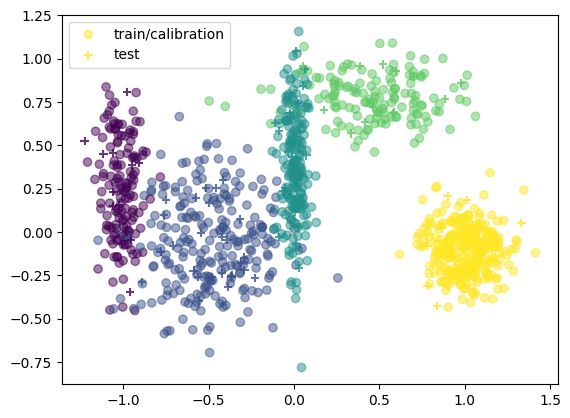

In [14]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:, 1],c=y, marker='o', alpha=0.5, label='train/calibration')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='+', alpha=0.8, label='test')
plt.legend()

In [20]:
n_test = 10000 
model = KMeans(n_clusters=3)
clf = RandomForestClassifier(random_state=0)
def compute_target(seed, X_tr, n_test, model=model, clf=clf):
    np.random.seed(seed)
    X_test, _ = generate_data(n_test)
    mean, se = Cluster_LOCO_Split(X_tr, X_test, model=model, clf=clf, K=3, seed=seed, error_metric=hinge_error, n_jobs=1)
    return mean, se 

In [24]:
from joblib import Parallel, delayed
B = 10000
seeds = np.random.randint(0, 100000, size=B)
results_pop = Parallel(n_jobs=-1, verbose=10)(delayed(compute_target)(seed, X_tr, n_test) for seed in seeds)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   12.8s
[Parallel(n_jobs=-1)]: Done  49 tasks      | elapsed:   13.4s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:   14.5s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   15.2s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   16.4s
[Parallel(n_jobs=-1)]: Done 117 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   18.4s
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:   19.6s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:   20.9s
[Parallel(n_jobs=-1)]: Done 201 tasks      | elapsed:   22.1s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:   23.2s
[Parallel(n_jobs=-1)]: Done 249 tasks      | elapsed:   24.7s
[Parallel(n_jobs=-1)]: Done 274 tasks      | elapsed:  

In [38]:
res

(array([0.41522, 0.05516]), array([0.36922588, 0.19403241]))

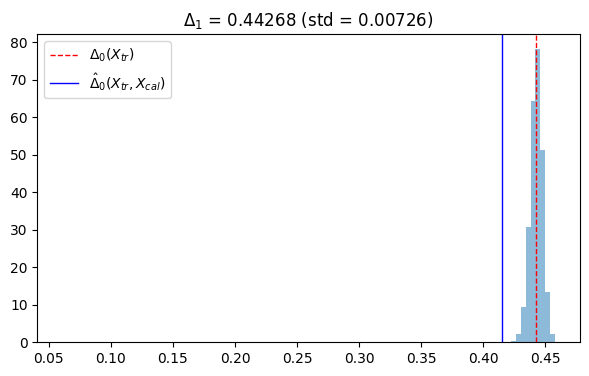

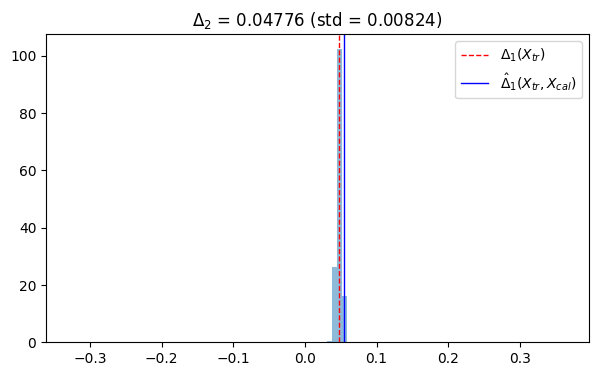

In [42]:
# unpack the results
Deltas_pop = np.array(results_pop)
Delta = np.mean(Deltas_pop, axis=0)

for j in range(2):
    plt.figure(figsize=(7,4))
    plt.hist(Deltas_pop[:,0,j], bins=100, density=True, alpha=0.5) #, color='b')
    plt.axvline(Delta[0, j], color='r', linestyle='dashed', linewidth=1, label=rf'$\Delta_{j}(X_{{tr}})$')
    plt.axvline(res[0][j], color='b', linestyle='-', linewidth=1, label=rf'$\hat \Delta_{{{j}}}(X_{{tr}}, X_{{cal}})$')
    plt.title(r'$\Delta_{%d}$ = %.5f (std = %.5f)' % (j+1, Delta[0, j], np.std(Deltas_pop[:, 0, j], ddof=1)))
    plt.legend()
    plt.show()
    

In [22]:
def estimate_mc(

(array([0.448631, 0.046111]), array([0.36569287, 0.20196501]))

In [23]:
res[0], res[1]

(array([0.41522, 0.05516]), array([0.36922588, 0.19403241]))